In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import (
accuracy_score,classification_report,confusion_matrix,
roc_auc_score,roc_curve,precision_recall_curve,average_precision_score
)
import warnings
warnings.filterwarnings("ignore")
print("库加载成功")

库加载成功


导入库
1.导入 NumPy 库，用于数值计算（数组、矩阵运算、数学函数）。
2.导入 Pandas 库，用于数据读取和处理（DataFrame）。
3.导入 Matplotlib 的 pyplot 模块，用于绘制图表（折线图、柱状图等）。
4.导入 Seaborn 库，基于 Matplotlib 的高级统计绘图库，提供更美观的图表。
5.导入 逻辑回归 分类器，这是本次核心模型。
6.导入数据划分工具 train_test_split 和超参数搜索器 GridSearchCV。
7.导入标准化器（用于缩放数值特征）和标签编码器（用于将类别特征转为数值）。
8.导入评估指标：准确率、分类报告、混淆矩阵、AUC-ROC、ROC 曲线、PR 曲线、平均精确率。
9.导入警告模块并忽略所有警告，保持输出整洁。

In [3]:
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
print(f"训练集形状:{train_df.shape}")
print(f"测试集形状:{test_df.shape}")
print(f"训练集列名：{train_df.columns.tolist}")
train_df.head()

训练集形状:(8693, 14)
测试集形状:(4277, 13)
训练集列名：<bound method IndexOpsMixin.tolist of Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')>


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


加载数据
1.读取训练集 CSV 文件，加载为 DataFrame train_df（约 8693 行，14 列）。
2.读取测试集 CSV 文件，加载为 DataFrame test_df（约 4277 行，13 列，无目标列）。
3.输出训练集形状，如 (8693, 14)。
4.输出测试集形状，如 (4277, 13)。
5.列出所有列名。
6.显示前 5 行数据，快速预览。

In [4]:
print(f"Transported分布:\n{train_df['Transported'].value_counts()}")
print(f"传送比例：{train_df['Transported'].mean():.2%}")
print(f"\n数值特征统计：")
print(train_df.describe())
print(f"\n缺失值数量：")
print(train_df.isnull().sum())

Transported分布:
Transported
True     4378
False    4315
Name: count, dtype: int64
传送比例：50.36%

数值特征统计：
               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000

数据探索
1.统计目标变量 Transported 中 True 和 False 的数量。
2.计算传送比例（约 50.36%），说明类别平衡。
3.输出数值特征的描述性统计（均值、标准差、分位数等）。
4.统计每列的缺失值数量。

In [5]:
df_train=train_df.copy()
df_test=test_df.copy()
df_train['Group']=df_train['PassengerId'].str.split('_').str[0].astype(int)
df_test['Group']=df_test['PassengerId'].str.split('_').str[0].astype(int)
df_train['Cabin']=df_train['Cabin'].fillna('Unknown/0/Unknown')
df_test['Cabin']=df_test['Cabin'].fillna('Unknown/0/Unknown')
for df in [df_train,df_test]:
    df['Deck']=df['Cabin'].str.split('/').str[0]
    df['CabinNum']=df['Cabin'].str.split('/').str[1].astype(float)
    df['Side']=df['Cabin'].str.split('/').str[2]
df_train['Surname']=df_train['Name'].str.split(' ').str[0]
df_test['Surname']=df_test['Name'].str.split(' ').str[0]
cat_cols = ['HomePlanet','CryoSleep','Destination','VIP', 'Deck','Side']
num_cols=['Age','RoomService','FoodCourt','ShoppingMall', 'Spa','VRDeck','CabinNum','Group']
target='Transported'
bool_cols=['CryoSleep', 'VIP']
for col in bool_cols:
    df_train[col]=df_train[col].astype(str)
    df_test[col]=df_test[col].astype(str)
for col in cat_cols:
    df_train[col]=df_train[col].fillna('Unknown')
    df_test[col]=df_test[col].fillna('Unknown')
for col in num_cols:
    median_val=df_train[col].median()
    df_train[col]=df_train[col].fillna(median_val)
    df_test[col]=df_test[col].fillna(median_val)
for col in cat_cols:
    le=LabelEncoder()
    combined=pd.concat([df_train[col],df_test[col]], axis=0).unique()
    le.fit(combined)
    df_train[col]=le.transform(df_train[col])
    df_test[col]=le.transform(df_test[col])
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
df_train['TotalSpend']=df_train[spend_cols].sum(axis=1)
df_test['TotalSpend']=df_test[spend_cols].sum(axis=1)
X_train=df_train.drop(columns=['PassengerId','Cabin','Name','Surname','Transported'])
y_train=df_train['Transported'].astype(int)
X_test=df_test.drop(columns=['PassengerId','Cabin','Name','Surname'])
passenger_ids=df_test['PassengerId']
print(f"特征数量：{X_train.shape[1]}")
print(f"特征列名：{X_train.columns.tolist()}")

特征数量：15
特征列名：['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Group', 'Deck', 'CabinNum', 'Side', 'TotalSpend']


特征工程（完美修复版）
1.复制数据，避免修改原始 DataFrame。
2.从 PassengerId（如 "1234_05"）中提取组号（第一个下划线前的数字），转换为整数，作为新特征 Group。同一组号可能表示属于同一个家庭或团队。
3.对测试集执行相同操作。
4.修复 Cabin 缺失值：在拆分前将缺失值替换为 'Unknown/0/Unknown'，使得拆分后各部分都有意义。
5.测试集同样处理。
6.遍历训练集和测试集，将 Cabin 列按 '/' 拆分为三部分：甲板（Deck）、编号（CabinNum）、侧边（Side）。编号转换为浮点数。
7.从姓名中提取第一个单词（姓氏），作为新特征。
8.定义类别特征列表、数值特征列表和目标变量名。
9.将布尔列（CryoSleep 和 VIP）转换为字符串，避免后续 LabelEncoder 因混合类型（布尔+字符串 'Unknown'）而报错。
10.对类别特征用 'Unknown' 填充缺失值（注意拼写正确）。
11.对数值特征用训练集的中位数填充缺失值（测试集也用训练集的中位数，不能使用测试集自身的中位数）。
12.对每个类别特征：合并训练集和测试集的所有取值后拟合编码器，然后分别转换，确保测试集中出现的新类别也有对应编码。
13.创建新特征 TotalSpend（总消费金额），综合五项消费。
14.删除无用列（ID、原始 Cabin、Name、Surname、目标列），得到训练特征矩阵 X_train 和目标向量 y_train（0/1）。
15.测试集同样删除无用列（不包括 Transported，因为测试集没有该列），得到测试特征矩阵 X_test，并保留 PassengerId 用于提交。
16.输出特征数量和列名，确认处理正确。

In [6]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_sub,X_val,y_train_sub,y_val=train_test_split(X_train_scaled,y_train,test_size=0.2,random_state=42,stratify=y_train)
print(f"训练子集：{X_train_sub.shape}")
print(f"验证集：{X_val.shape}")

训练子集：(6954, 15)
验证集：(1739, 15)


标准化与数据划分
1.创建一个标准化器，将每个特征减去均值并除以标准差，使其服从标准正态分布（均值0，方差1）。
2.在训练集上拟合（计算每列的均值和标准差），然后转换训练数据。
3.用训练集的统计量转换测试集，绝不能重新拟合，保证测试集与训练集处于同一尺度。
4.将标准化后的训练数据划分为训练子集（80%）和验证集（20%），使用分层抽样（stratify=y_train）保证类别比例一致，固定随机种子 random_state=42。
5.输出划分后的形状。

In [7]:
lr=LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train_sub,y_train_sub)
y_pred=lr.predict(X_val)
y_prob=lr.predict_proba(X_val)[:,1]
print("逻辑回归结果")
print(f"准确率：{accuracy_score(y_val,y_pred):.4f}")
print(f"AUC_POC：{roc_auc_score(y_val,y_prob):.4f}")
print("\n分类报告")
print(classification_report(y_val,y_pred,target_names=['未传送','传送']))

逻辑回归结果
准确率：0.7844
AUC_POC：0.8695

分类报告
              precision    recall  f1-score   support

         未传送       0.80      0.75      0.78       863
          传送       0.77      0.82      0.79       876

    accuracy                           0.78      1739
   macro avg       0.79      0.78      0.78      1739
weighted avg       0.79      0.78      0.78      1739



训练基础逻辑回归
1.创建一个逻辑回归分类器：默认 L2 正则化，C=1.0，最大迭代次数 1000（保证收敛）。
2.在训练子集上训练模型。逻辑回归使用梯度下降（或拟牛顿法）最小化对数损失。
3.在验证集上预测类别（默认阈值 0.5）。
4.获取预测为正类（传送）的概率，用于计算 AUC-ROC。
5.输出准确率、AUC-ROC 和分类报告（精确率、召回率、F1-score）。

In [8]:
param_grid={
    'C':[0.01,0.1,1,10,100],
    'penalty':['l1','l2'],
    'solver':['liblinear']
}
grid=GridSearchCV(LogisticRegression(random_state=42,max_iter=1000),param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=0)
grid.fit(X_train_sub,y_train_sub)
print(f"最佳参数:{grid.best_params_}")
print(f"最佳交叉验证得分：{grid.best_score_:.4f}")
best_lr=LogisticRegression(**grid.best_params_,random_state=42,max_iter=1000)
best_lr.fit(X_train_sub,y_train_sub)
y_pred_best=best_lr.predict(X_val)
y_prob_best=best_lr.predict_proba(X_val)[:,1]
val_acc=accuracy_score(y_val,y_pred_best)
print(f"调参后验证集准确率:{val_acc:.4f}")

最佳参数:{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
最佳交叉验证得分：0.7885
调参后验证集准确率:0.7844


网格搜索调参
1.定义参数搜索空间：C（正则化强度）、penalty（L1/L2）、solver（liblinear 支持 L1 和 L2）。
2.创建网格搜索对象：估计器为逻辑回归，5 折交叉验证，评分指标为准确率，使用所有 CPU 核心并行计算。
3.执行网格搜索，对每种参数组合进行 5 折交叉验证，记录最佳结果。
4.输出最佳参数组合和对应的交叉验证平均准确率。
5.用最佳参数重新创建逻辑回归模型。
6.在训练子集上重新训练最佳模型。
7.在验证集上评估调参后的模型，计算准确率并输出。

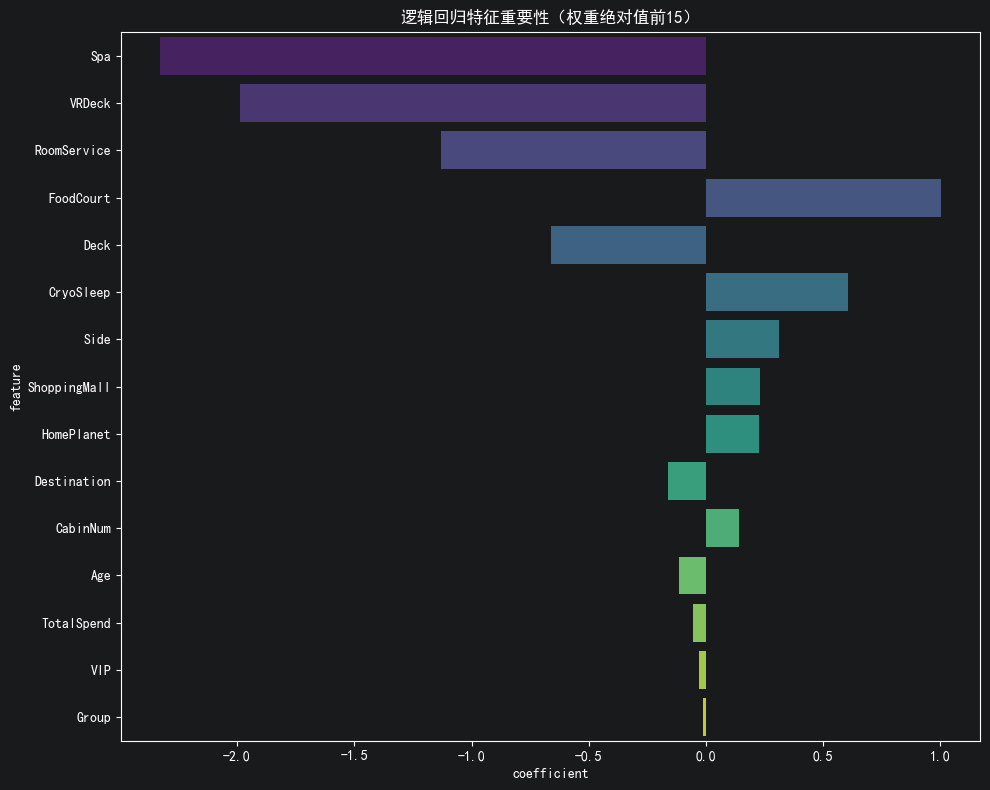

前10个特征权重：
     feature  coefficient
         Spa    -2.328471
      VRDeck    -1.985983
 RoomService    -1.129631
   FoodCourt     1.002086
        Deck    -0.660003
   CryoSleep     0.603753
        Side     0.312287
ShoppingMall     0.230444
  HomePlanet     0.225080
 Destination    -0.161526


In [10]:
coef=pd.DataFrame({'feature':X_train.columns,'coefficient':best_lr.coef_[0]}).sort_values('coefficient',key=abs,ascending=False)
plt.rcParams['font.sans-serif']=['SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(10,8))
sns.barplot(data=coef.head(15),x='coefficient',y='feature',palette='viridis')
plt.title('逻辑回归特征重要性（权重绝对值前15）')
plt.tight_layout()
plt.show()
print("前10个特征权重：")
print(coef.head(10).to_string(index=False))

特征重要性分析
1.创建 DataFrame，包含特征名和对应的逻辑回归权重（coef_[0] 是形状 (1, n_features) 的数组，取第 0 行）。
2.按权重绝对值降序排列，找出最重要的特征。
3.创建宽 10 英寸、高 8 英寸的画布。
4.绘制水平条形图，显示前 15 个最重要特征的权重。正权重表示特征越大，传送概率越高；负权重相反。
5.设置标题，自动调整布局，显示图像。
6.	以表格形式打印前 10 个特征权重。

In [11]:
test_pred=best_lr.predict(X_test_scaled)
submission=pd.DataFrame({'PassengerId':passenger_ids,'Transported':test_pred.astype(bool)})
submission.to_csv('submission_logistic.csv',index=False)
print("提交文件已生成：submission_logistic.csv")
print(submission.head())

提交文件已生成：submission_logistic.csv
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True


生成 Kaggle 提交文件
1.用最佳模型对标准化后的测试集进行预测，得到 0/1 整数数组。
2.创建提交 DataFrame：PassengerId（测试集的乘客 ID）和 Transported（预测结果，用 .astype(bool) 转换为布尔值 True/False，符合 Kaggle 要求）。
3.保存为 CSV 文件，不含行索引。
4.确认文件生成，并预览前 5 行。